# Experiment Runs — Data-Aware DAG Scheduling in Federated Fog Systems

This notebook stores the test runs behind Section VI of the paper. It

1. builds the test datasets (workflow DAGs + fog federations) at several sizes,
2. runs the four schedulers on each dataset and records score / makespan /
   deadline feasibility / wall time into `data/results/test_runs.csv`,
3. draws the workflow DAG and the fog resource graph for each dataset, and
4. reloads the sweep CSVs (`slack`, `nodes`, `size`, `failure`, `bandwidth`)
   and renders the comparative figures.

Run all cells from the project root. Requires NumPy, SciPy, pandas,
matplotlib, and networkx.

In [1]:
# imports and path setup so the notebook can use the simulator package
import os, sys, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# works whether the kernel is started in notebooks/ or the repo root
_cwd = os.getcwd()
ROOT = _cwd if os.path.isdir(os.path.join(_cwd, "code")) else os.path.dirname(_cwd)
sys.path.insert(0, os.path.join(ROOT, "code"))

from fogsim import (INST_DIR, RES_DIR,
                    generate_instance, save_instance, evaluate)

pd.set_option("display.float_format", lambda x: f"{x:.3f}")

### Why these datasets match the paper's story

The paper motivates the problem with disaster-response workflows running on
federated fog sites (flood forecasting, spill simulation, evacuation
planning). The generator parameters are chosen to be plausible for that
setting, in normalized units:

- **Task execution times** $t_{ia} \in [1,5]$ on the fastest node — think of
  minutes for a simulation or preprocessing stage, not milliseconds.
- **Edge data sizes** $D_{ji} \in [5,50]$ — intermediate results such as
  sensor batches, model features, or checkpoint fragments; large enough that
  transfers matter on realistic fog links.
- **Link bandwidths** $B_{ba} \in [10,100]$ — Mbps-class wireless/LAN links
  between nearby sites; transfer times $D_{ji}/B_{ba}$ then land in the same
  range as task times, which is exactly the regime where placement decisions
  are interesting. If $D/B \ll t$ the problem degenerates to compute-only
  scheduling; if $D/B \gg t$ remote placement is never viable. We sit in the
  contested middle.
- **Node speeds** $\in [0.5,2]\times$ — modest heterogeneity, matching
  commodity fog hardware.
- **Deadline** $t_{\max} = \alpha \cdot T_{cp}$ where $T_{cp}$ is the
  critical path at full execution — so $\alpha = 1.0$ is genuinely tight and
  larger $\alpha$ models a less urgent alert deadline.
- **Eligibility** $P_{ia}$ drops ~15% of task–node pairs — a node may lack a
  sensor feed or a required library.

These choices are what make the figures tell the intended story: the scheduler
has to trade execution time against data-transfer time, and approximate
execution is a real lever when $\alpha$ is close to 1.

## 1. Test datasets

Four datasets spanning the workflow sizes used in the paper. The two large
datasets use a sparser DAG (density 0.02) so the edge count stays realistic
for a workflow of that scale. Small/medium instances are also written to
`data/instances/` as JSON; the large ones are kept in memory because their
dense JSON dumps would be tens of MB.

In [2]:
# the four datasets used below: 10 tasks up to 1000 tasks
# (density is lowered on the big ones so the edge count stays realistic)
configs = [
    dict(name="small",  n_tasks=10,   n_nodes=3,  alpha=1.2, density=0.15, seed=0),
    dict(name="medium", n_tasks=100,  n_nodes=5,  alpha=1.5, density=0.15, seed=1),
    dict(name="large",  n_tasks=500,  n_nodes=8,  alpha=1.5, density=0.02, seed=2),
    dict(name="xlarge", n_tasks=1000, n_nodes=10, alpha=1.5, density=0.02, seed=3),
]

instances, rows = {}, []
os.makedirs(INST_DIR, exist_ok=True)
for cfg in configs:
    t0 = time.time()
    inst = generate_instance(**{k: v for k, v in cfg.items() if k != "name"})
    instances[cfg["name"]] = inst
    rows.append(dict(dataset=cfg["name"], tasks=inst.n, edges=len(inst.edges),
                     fog_nodes=inst.m, deadline_s=round(inst.t_max, 2),
                     gen_time_s=round(time.time() - t0, 1)))
    if inst.n <= 200:                      # keep committed JSONs small
        path = os.path.join(
            INST_DIR,
            f"dag{inst.n}_nodes{inst.m}_a{cfg['alpha']}_s{cfg['seed']}.json")
        save_instance(inst, path)

datasets = pd.DataFrame(rows)
datasets

,dataset,tasks,edges,fog_nodes,deadline_s,gen_time_s
0,small,10,10,3,20.200,0.000
1,medium,100,748,5,62.170,0.000
2,large,500,2512,8,72.920,0.100
3,xlarge,1000,9806,10,120.040,0.200


## 2. Test runs

Every dataset is scheduled by every applicable method. The MILP is skipped
above 800 assignment variables (`n*m`), as in the paper; randomized
rounding is skipped on the two largest datasets because it re-solves the
LP 40 times per run. Results are appended to `data/results/test_runs.csv`.

In [3]:
# run every applicable scheduler on every dataset
# (MILP is skipped past 800 assignment variables, and rounding on the two
# largest datasets where 40 LP re-solves would take too long)
runs = []
for name, inst in instances.items():
    for method in ["milp", "rounding", "greedy", "ga"]:
        if method == "milp" and inst.n * inst.m > 800:
            continue
        if method == "rounding" and inst.n > 200:
            continue
        r = evaluate(inst, method, seed=0)
        runs.append(dict(dataset=name, method=method, **r))
        print(f"{name:6s} {method:9s} score={r['score']:.3f} "
              f"makespan={r['makespan']:.2f} feasible={r['feasible']} "
              f"({r['runtime_s']:.1f}s)")

test_runs = pd.DataFrame(runs)
out_csv = os.path.join(RES_DIR, "test_runs.csv")
test_runs.to_csv(out_csv, index=False)
print("wrote", out_csv)
test_runs

small  milp      score=1.637 makespan=17.98 feasible=1 (0.0s)
small  rounding  score=1.637 makespan=17.98 feasible=1 (0.2s)
small  greedy    score=1.637 makespan=16.84 feasible=1 (0.0s)


small  ga        score=1.637 makespan=18.90 feasible=1 (0.3s)


medium milp      score=1.443 makespan=60.94 feasible=1 (1.4s)


medium rounding  score=1.324 makespan=62.17 feasible=1 (24.8s)
medium greedy    score=1.443 makespan=43.11 feasible=1 (0.0s)


medium ga        score=1.274 makespan=61.26 feasible=1 (5.2s)
large  greedy    score=1.419 makespan=50.15 feasible=1 (0.0s)


large  ga        score=1.173 makespan=71.26 feasible=1 (21.4s)
xlarge greedy    score=1.406 makespan=83.14 feasible=1 (0.1s)


xlarge ga        score=1.126 makespan=119.85 feasible=1 (73.0s)
wrote /Users/gayanigupta/Documents/data-aware-scheduling/Final_Submission_IEEE/code/fogsim/../../data/results/test_runs.csv


,dataset,method,score,makespan,feasible,runtime_s
0,small,milp,1.637,17.976,1,0.013
1,small,rounding,1.637,17.976,1,0.163
2,small,greedy,1.637,16.836,1,0.000
3,small,ga,1.637,18.901,1,0.272
4,medium,milp,1.443,60.939,1,1.373
5,medium,rounding,1.324,62.167,1,24.832
6,medium,greedy,1.443,43.109,1,0.003
7,medium,ga,1.274,61.259,1,5.192
8,large,greedy,1.419,50.149,1,0.038
9,large,ga,1.173,71.260,1,21.432


## 3. Workflow DAG and resource graph per dataset

Left: the workflow DAG (edges carry data size $D_{ji}$). For the large
datasets only a 60-task prefix is drawn — the full graph is not readable at
print size. Right: the fog federation resource graph; edge thickness is
proportional to link bandwidth $B_{ba}$.

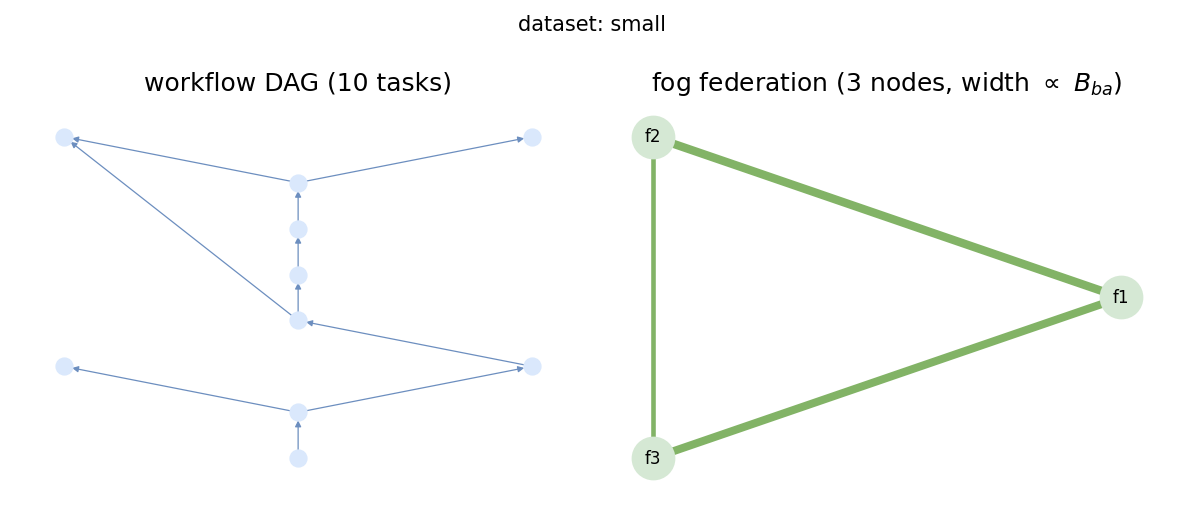

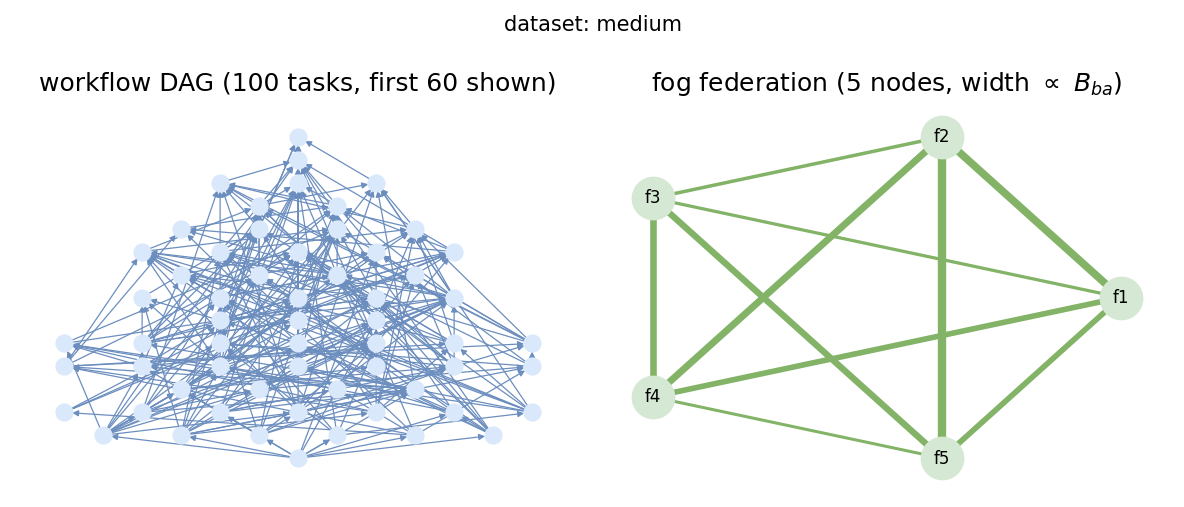

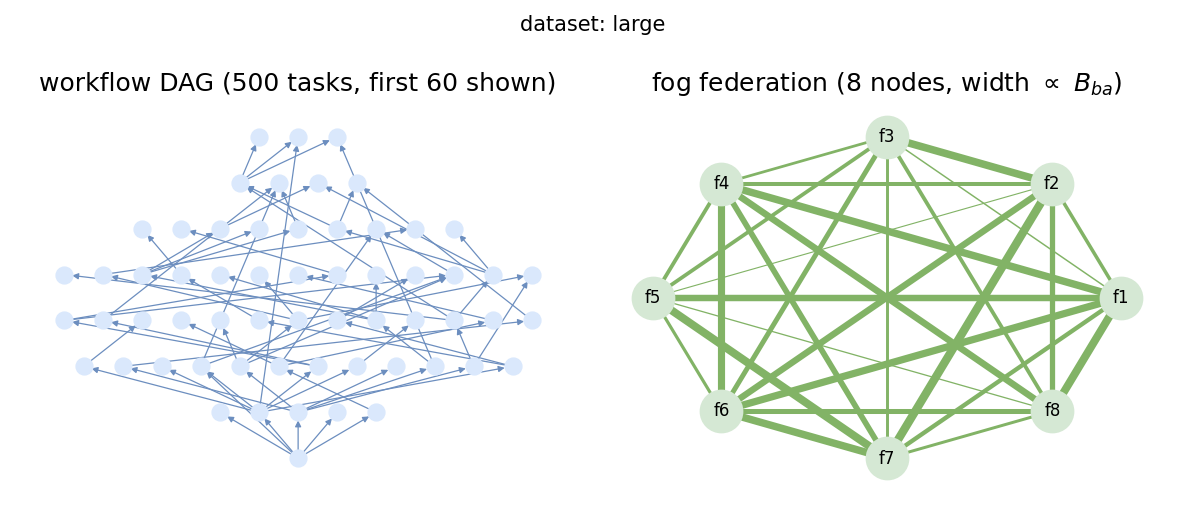

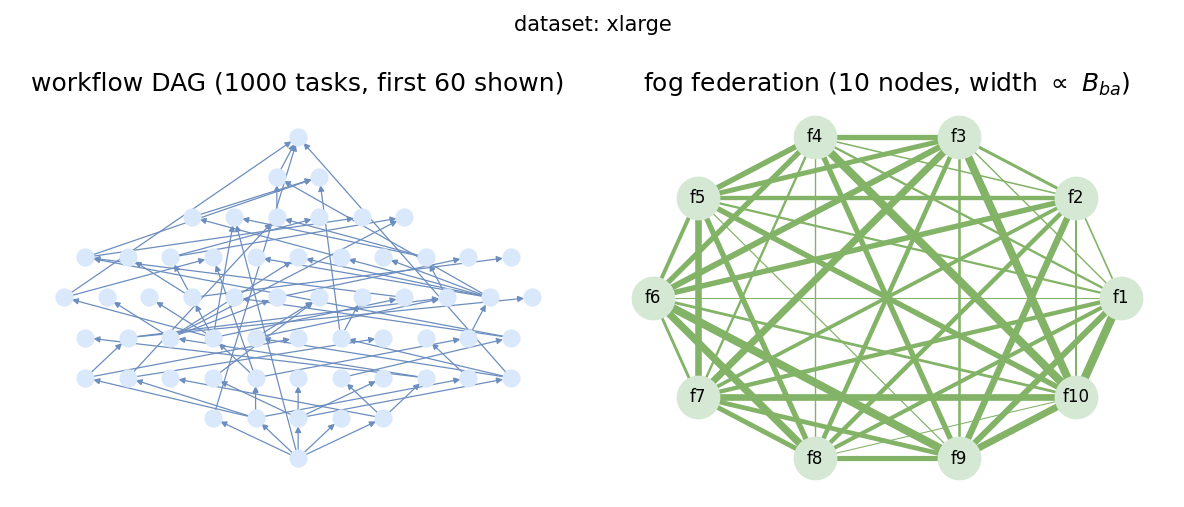

In [4]:
def draw_workflow_dag(inst, ax, max_nodes=60):
    keep = set(inst.order[:max_nodes])
    g = nx.DiGraph()
    g.add_nodes_from(keep)
    g.add_edges_from((j, i) for (j, i) in inst.edges
                     if j in keep and i in keep)
    layers = {}
    for i in inst.order[:max_nodes]:        # layer = distance from a source
        layers[i] = max((layers[j] + 1 for j in inst.preds[i]
                         if j in layers), default=0)
    nx.set_node_attributes(g, layers, "layer")
    pos = nx.multipartite_layout(g, subset_key="layer", align="horizontal")
    nx.draw(g, pos, ax=ax, node_size=60, node_color="#dae8fc",
            edge_color="#6c8ebf", arrows=True, arrowsize=6, width=0.6,
            with_labels=False)
    ax.set_title(f"workflow DAG ({inst.n} tasks"
                 + (f", first {max_nodes} shown)" if inst.n > max_nodes else ")"))


def draw_resource_graph(inst, ax):
    g = nx.Graph()
    g.add_nodes_from(range(inst.m))
    for b in range(inst.m):
        for a in range(b + 1, inst.m):
            g.add_edge(b, a, weight=inst.B[b, a])
    pos = nx.circular_layout(g)
    w = np.array([g[b][a]["weight"] for b, a in g.edges])
    nx.draw(g, pos, ax=ax, with_labels=True,
            labels={i: f"f{i+1}" for i in g.nodes},
            node_color="#d5e8d4", edge_color="#82b366",
            width=4 * w / w.max(), node_size=400, font_size=8)
    ax.set_title(f"fog federation ({inst.m} nodes, width $\\propto$ $B_{{ba}}$)")


for name, inst in instances.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.4), dpi=150)
    draw_workflow_dag(inst, ax1)
    draw_resource_graph(inst, ax2)
    fig.suptitle(f"dataset: {name}", fontsize=10)
    fig.tight_layout()
    fig.savefig(os.path.join(ROOT, "data", "results",
                             f"dataset_{name}_graphs.png"),
                bbox_inches="tight", facecolor="white")
    plt.show()

## 4. Sweep results

Reload the sweep CSVs produced by `python3 code/fogsim.py sweep <kind>` and
render the four comparative figures (same output as `fogsim.py plot`).

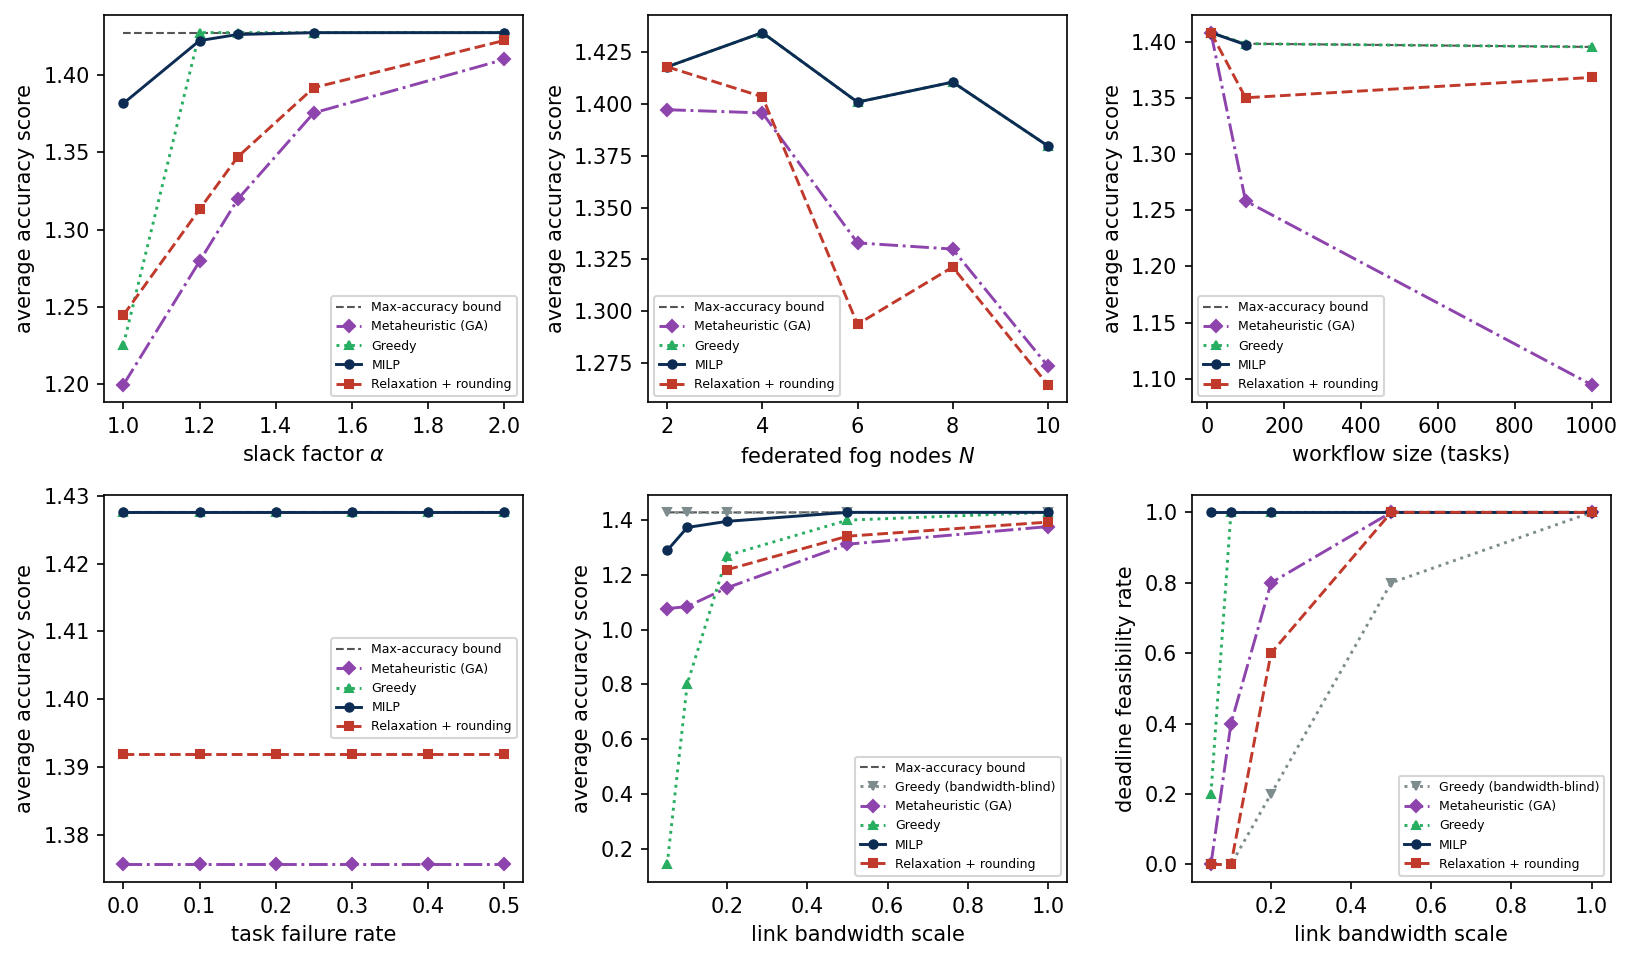

== slack ==
method    ga  greedy  milp  rounding
param                               
1.000  1.200   1.226 1.382     1.245
1.200  1.280   1.428 1.422     1.313
1.300  1.320   1.428 1.426     1.347
1.500  1.376   1.428 1.428     1.392
2.000  1.410   1.428 1.428     1.422

== nodes ==
method    ga  greedy  milp  rounding
param                               
2      1.397   1.418 1.418     1.418
4      1.396   1.435 1.435     1.404
6      1.333   1.401 1.401     1.294
8      1.330   1.411 1.411     1.321
10     1.273   1.380 1.380     1.264

== size ==
method    ga  greedy  milp  rounding
param                               
10     1.409   1.409 1.409     1.409
100    1.259   1.399 1.398     1.351
1000   1.095   1.396   NaN     1.369

== failure ==
method    ga  greedy  milp  rounding
param                               
0.000  1.376   1.428 1.428     1.392
0.100  1.376   1.428 1.428     1.392
0.200  1.376   1.428 1.428     1.392
0.300  1.376   1.428 1.428     1.392
0.400  1.376   1.428 1.

In [5]:
# same colors/markers as code/fogsim/experiments.py plot() so the figures
# below match the PNGs that go into the paper
style = {"milp":     dict(marker="o", ls="-",  color="#0d2c54", label="MILP"),
         "rounding": dict(marker="s", ls="--", color="#c0392b", label="Relaxation + rounding"),
         "greedy":   dict(marker="^", ls=":",  color="#27ae60", label="Greedy"),
         "ga":       dict(marker="D", ls="-.", color="#8e44ad", label="Metaheuristic (GA)"),
         "blind":    dict(marker="v", ls=":",  color="#7f8c8d", label="Greedy (bandwidth-blind)")}
xlabel = {"slack": r"slack factor $\alpha$", "nodes": "federated fog nodes $N$",
          "size": "workflow size (tasks)", "failure": "task failure rate",
          "bandwidth": "link bandwidth scale"}

# one panel per sweep; the dashed grey line is the max-accuracy bound
# (full execution, deadline ignored) for the same instances.  The last
# panel shows deadline feasibility for the bandwidth sweep -- score alone
# is misleading there, because the blind baseline executes everything
# fully but finishes late.
kinds = ["slack", "nodes", "size", "failure", "bandwidth"]
fig, axes = plt.subplots(2, 3, figsize=(11, 6.5), dpi=150)
for ax, kind in zip(axes.flat, kinds):
    csv = os.path.join(RES_DIR, f"{kind}.csv")
    if not os.path.exists(csv):
        ax.set_title(f"{kind}: run `fogsim.py sweep {kind}` first")
        continue
    df = pd.read_csv(csv).dropna(subset=["score"])
    if "bound" in df.columns:
        bnd = df.groupby("param")["bound"].mean()
        ax.plot(bnd.index, bnd.values, color="#555555", ls="--", lw=1.0,
                label="Max-accuracy bound")
    for meth, g in df.groupby("method"):
        mean = g.groupby("param")["score"].mean()
        ax.plot(mean.index, mean.values, **style[meth], lw=1.4, ms=4)
    ax.set_xlabel(xlabel[kind]); ax.set_ylabel("average accuracy score")
    ax.legend(fontsize=6)

ax = axes.flat[len(kinds)]
bw_csv = os.path.join(RES_DIR, "bandwidth.csv")
if os.path.exists(bw_csv):
    df = pd.read_csv(bw_csv)
    for meth, g in df.groupby("method"):
        feas = g.groupby("param")["feasible"].mean()
        ax.plot(feas.index, feas.values, **style[meth], lw=1.4, ms=4)
    ax.set_xlabel(xlabel["bandwidth"]); ax.set_ylabel("deadline feasibility rate")
    ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=6)
else:
    ax.set_title("bandwidth feasibility: run `fogsim.py sweep bandwidth` first")
fig.tight_layout()
plt.show()

# the same numbers as tables, for easy inspection
summary = {k: pd.read_csv(os.path.join(RES_DIR, f"{k}.csv"))
           for k in kinds
           if os.path.exists(os.path.join(RES_DIR, f"{k}.csv"))}
for k, df in summary.items():
    print(f"== {k} ==")
    print(df.groupby(["param", "method"])["score"].mean().unstack().round(3))
    print()
if "bandwidth" in summary:
    print("== bandwidth feasibility ==")
    print(summary["bandwidth"].groupby(["param", "method"])["feasible"]
          .mean().unstack().round(2))

## 5. Very large workflow DAGs (structure only)

Workflows up to $10^6$ tasks, generated as edge lists with a vectorized sampler (each task draws $k$ predecessors uniformly from earlier tasks, so the graph is acyclic and has $\approx k \cdot n$ edges). These datasets capture the *graph structure* only: the dense per-edge data model used by the schedulers needs an $n \times n$ matrix, so scheduling runs stay at $n \le 1000$ — beyond that we report structural stats (edges, depth, sources/sinks) and a sampled drawing.

In [6]:
def gen_dag_edges(n, k=3, seed=0):
    """Acyclic edge list: every task i>=1 gets k predecessors drawn
    uniformly from {0,...,i-1}.  O(n*k) memory, works to n=10**6."""
    rng = np.random.default_rng(seed)
    dst = np.repeat(np.arange(1, n, dtype=np.int64), k)
    src = (rng.random(dst.size) * dst).astype(np.int64)      # src < dst
    key = src * n + dst
    key = np.unique(key)                                     # drop dup edges
    return np.stack([key // n, key % n], axis=1)


def dag_stats(edges, n):
    depth = np.zeros(n, dtype=np.int64)
    deg = np.zeros(n, dtype=np.int64)
    # edges are sorted by source, so when (j, i) is reached every edge
    # into j has already been processed and depth[j] is final
    for j, i in edges:
        depth[i] = max(depth[i], depth[j] + 1)
        deg[i] += 1
    sinks = int(np.sum(np.bincount(edges[:, 0], minlength=n) == 0))
    return dict(tasks=n, edges=len(edges), depth=int(depth.max()),
                sources=int(np.sum(deg == 0)), sinks=sinks,
                avg_indegree=round(len(edges) / n, 2))


big_rows, big_graphs = [], {}
for n in [10**2, 10**3, 10**4, 10**5, 10**6]:
    t0 = time.time()
    edges = gen_dag_edges(n)
    row = dag_stats(edges, n)
    row["gen_time_s"] = round(time.time() - t0, 1)
    big_rows.append(row)
    big_graphs[n] = edges
    if n <= 10**4:                       # keep committed edge lists modest
        np.savetxt(os.path.join(ROOT, "data", "instances",
                                f"dag{n}_edgelist.csv"),
                   edges, fmt="%d", delimiter=",")

graph_datasets = pd.DataFrame(big_rows)
graph_datasets.to_csv(os.path.join(RES_DIR, "graph_datasets.csv"),
                      index=False)
graph_datasets

,tasks,edges,depth,sources,sinks,avg_indegree,gen_time_s
0,100,284,24,1,23,2.840,0.000
1,1000,2978,39,1,253,2.980,0.000
2,10000,29971,57,1,2509,3.000,0.000
3,100000,299966,73,1,25155,3.000,0.300
4,1000000,2999961,91,1,249933,3.000,3.100


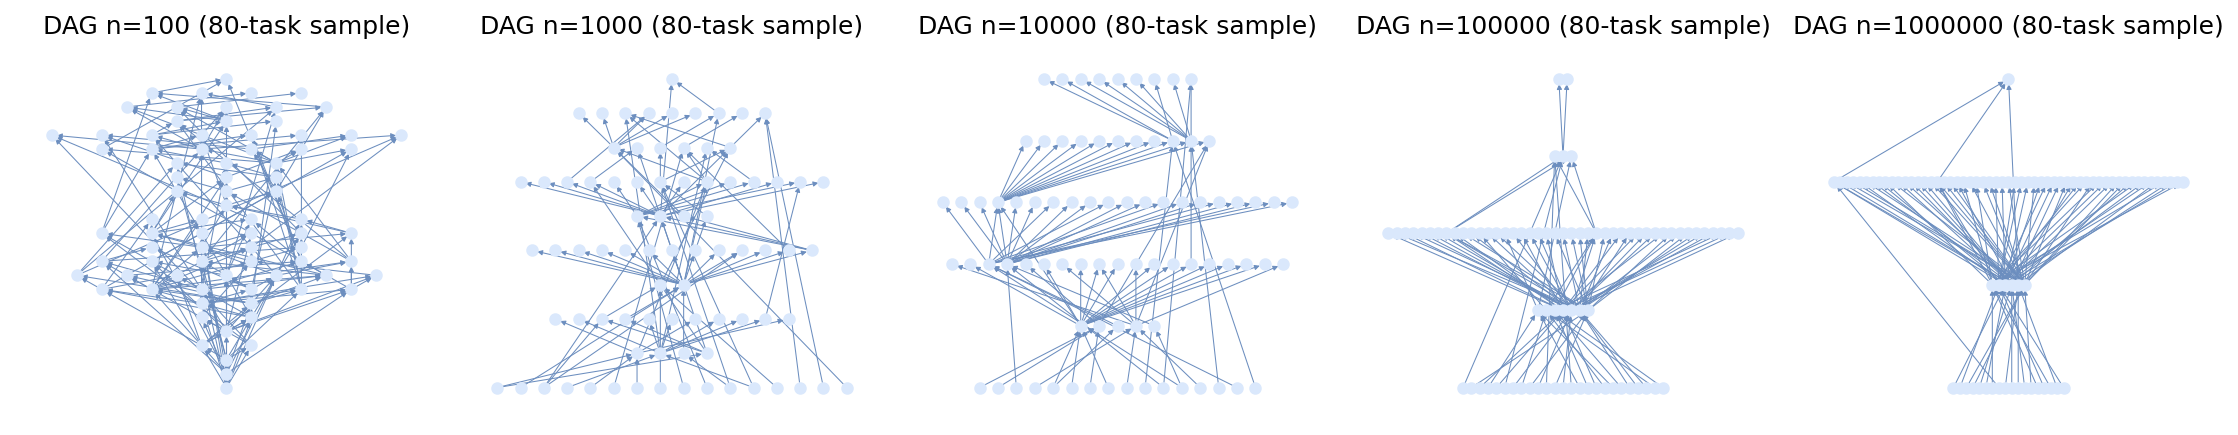

In [7]:
# Sampled views of the large DAGs: a depth-bounded neighbourhood around a
# random task keeps the drawing readable at any dataset size.
def draw_edge_list_dag(edges, n, ax, sample=80, seed=0):
    g = nx.from_edgelist(edges, create_using=nx.DiGraph)
    rng = np.random.default_rng(seed)
    if n > sample:
        start = int(rng.integers(n))
        sub = nx.bfs_tree(g.to_undirected(), start, depth_limit=4)
        sub = g.subgraph(list(sub.nodes)[:sample])
    else:
        sub = g
    sub = nx.DiGraph(sub)
    # longest-path layering inside the sampled subgraph
    lv = {u: 0 for u in nx.topological_sort(sub)}
    for u in nx.topological_sort(sub):
        for v in sub.successors(u):
            lv[v] = max(lv[v], lv[u] + 1)
    nx.set_node_attributes(sub, lv, "layer")
    pos = nx.multipartite_layout(sub, subset_key="layer",
                                 align="horizontal")
    nx.draw(sub, pos, ax=ax, node_size=25, node_color="#dae8fc",
            edge_color="#6c8ebf", arrows=True, arrowsize=5, width=0.5,
            with_labels=False)
    ax.set_title(f"DAG n={n} ({len(sub)}-task sample)")


fig, axes = plt.subplots(1, 5, figsize=(15, 3.0), dpi=150)
for ax, (n, edges) in zip(axes, big_graphs.items()):
    draw_edge_list_dag(edges, n, ax)
fig.tight_layout()
fig.savefig(os.path.join(RES_DIR, "large_dag_samples.png"),
            bbox_inches="tight", facecolor="white")
plt.show()

## 6. Resource graphs at different federation sizes

Fog federations from 10 up to $10^6$ nodes. Two things change at that scale. First, a complete graph is both unrealistic — fog sites peer with nearby sites, not with every other site — and impossible to store ($\sim 5\times10^{11}$ links at $m=10^6$). So each federation is generated the way a real deployment looks: sites at random positions, each linked to its four nearest neighbors, with link bandwidths in $[10,100]$. That is $O(m \cdot k)$ edges and works all the way to $10^6$.

The drawings show a spatially-coherent region (one corner of the deployment) for the larger federations; the stats table covers the full graph.</cell>

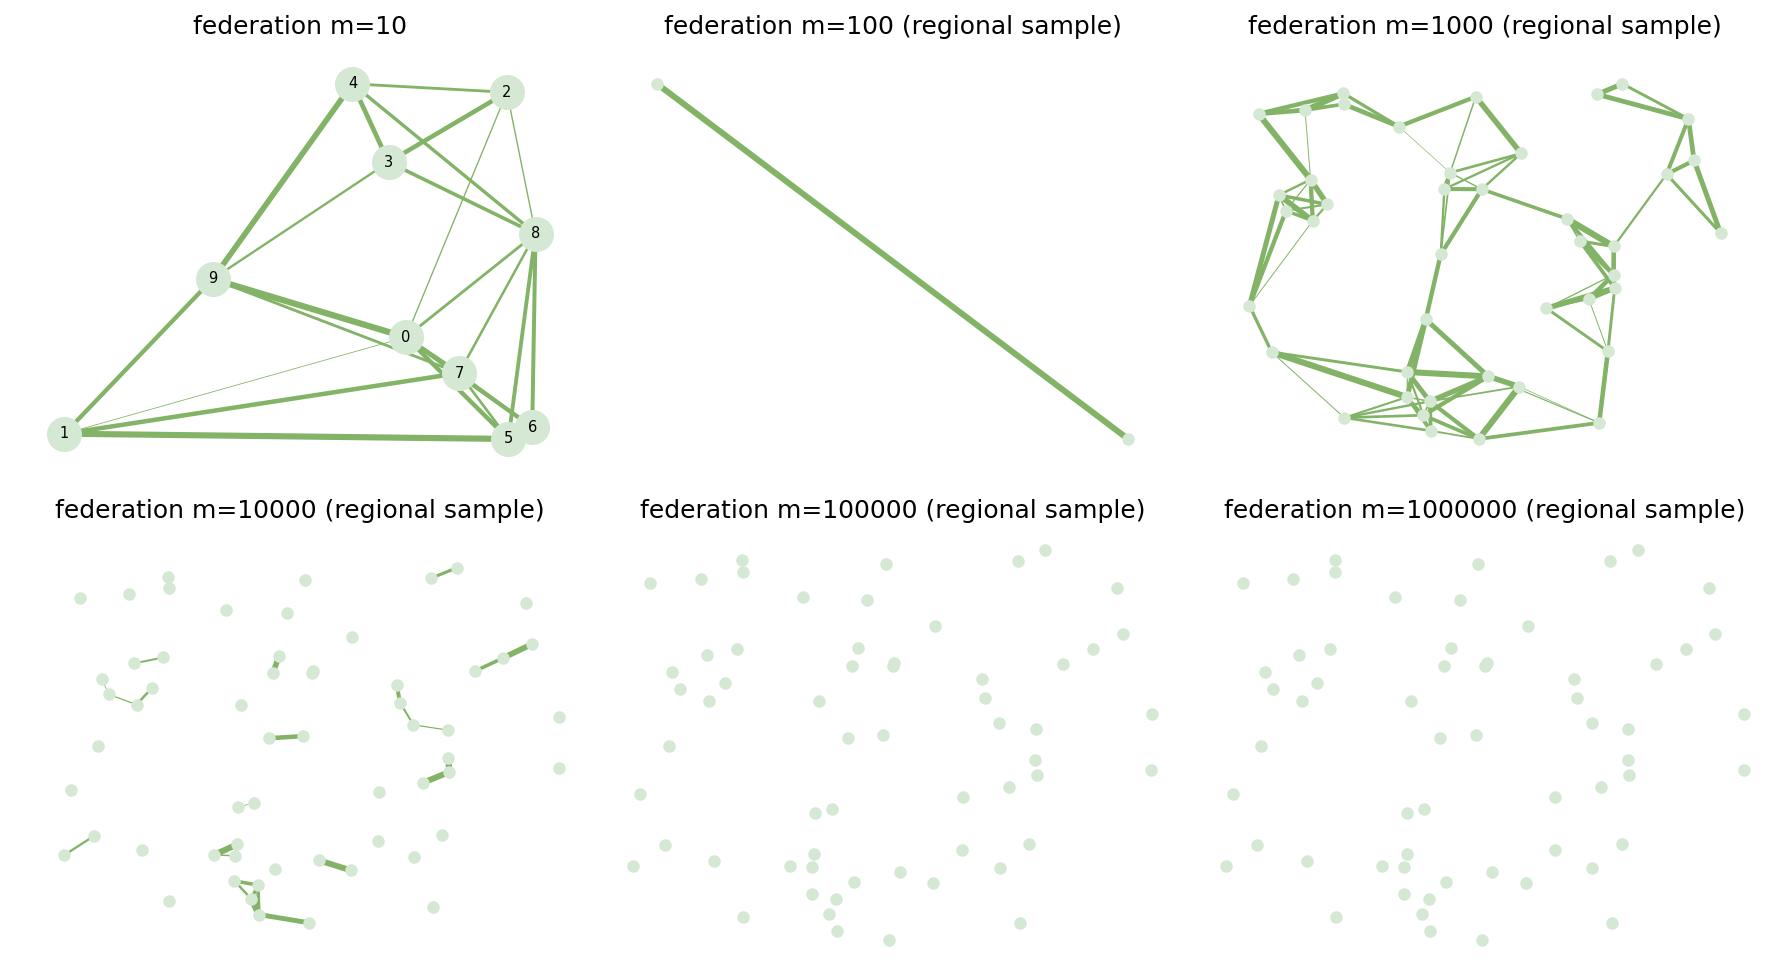

,fog_nodes,links,avg_degree,bw_min,bw_mean,bw_max,gen_time_s
0,10,25,5.000,12.500,58.400,99.700,0.000
1,100,255,5.100,10.000,57.700,99.700,0.000
2,1000,2428,4.900,10.000,54.700,100.000,0.000
3,10000,24213,4.800,10.000,55.000,100.000,0.040
4,100000,242552,4.900,10.000,55.100,100.000,0.470
5,1000000,2425240,4.900,10.000,55.000,100.000,7.340


In [8]:
from scipy.spatial import cKDTree


def gen_fog_graph(m, k=4, seed=0):
    """Sparse resource graph: m fog sites at random 2-D positions, each
    linked to its k nearest neighbors -- the way a real federated
    deployment actually connects.  O(m*k) edges, works to m=10**6.
    Returns (edges, bandwidths, positions)."""
    rng = np.random.default_rng(seed)
    xy = rng.random((m, 2))
    nbrs = cKDTree(xy).query(xy, k=min(k + 1, m))[1]   # col 0 is self
    links = set()
    for a in range(m):
        for b in np.atleast_1d(nbrs[a][1:]):
            links.add((min(a, int(b)), max(a, int(b))))
    e = np.array(sorted(links))
    bw = rng.uniform(10.0, 100.0, len(e))
    return e, bw, xy


def draw_fog_sample(edges, bw, xy, m, ax):
    # for big federations draw one corner region; small ones fit whole
    if m <= 60:
        keep = set(range(m))
    else:
        keep = set(np.nonzero((xy[:, 0] < 0.2) & (xy[:, 1] < 0.2))[0][:60])
    pos = {i: xy[i] for i in keep}
    g = nx.Graph()
    g.add_nodes_from(keep)
    for (a, b), w in zip(edges, bw):
        if a in keep and b in keep:
            g.add_edge(int(a), int(b), weight=float(w))
    widths = 3 * np.array([g[a][b]["weight"] for a, b in g.edges]) / 100.0
    nx.draw(g, pos, ax=ax, node_size=250 if m <= 12 else 25,
            node_color="#d5e8d4", edge_color="#82b366", width=widths,
            with_labels=m <= 12, font_size=7)
    ax.set_title(f"federation m={m}" + ("" if m <= 60 else " (regional sample)"))


res_rows = []
sizes = [10, 100, 10**3, 10**4, 10**5, 10**6]
fig, axes = plt.subplots(2, 3, figsize=(12, 6.6), dpi=150)
for ax, m in zip(axes.flat, sizes):
    t0 = time.time()
    e, bw, xy = gen_fog_graph(m)
    gen_s = time.time() - t0
    res_rows.append(dict(fog_nodes=m, links=len(e),
                         avg_degree=round(2 * len(e) / m, 1),
                         bw_min=round(bw.min(), 1),
                         bw_mean=round(bw.mean(), 1),
                         bw_max=round(bw.max(), 1),
                         gen_time_s=round(gen_s, 2)))
    draw_fog_sample(e, bw, xy, m, ax)
    if m <= 10**4:                       # keep committed edge lists modest
        np.savetxt(os.path.join(ROOT, "data", "instances",
                                f"fog{m}_edgelist.csv"),
                   e, fmt="%d", delimiter=",")
fig.tight_layout()
fig.savefig(os.path.join(RES_DIR, "resource_graphs.png"),
            bbox_inches="tight", facecolor="white")
plt.show()

res_graphs = pd.DataFrame(res_rows)
res_graphs.to_csv(os.path.join(RES_DIR, "resource_graphs.csv"), index=False)
res_graphs

## 7. What goes wrong on large datasets

Running the experiments at bigger sizes taught us a few things, so they are worth writing down honestly.

The first problem is memory. The schedulable instance stores edge data in a full $n \times n$ matrix, which already needs around 80 GB at $10^5$ tasks. Past $n = 10^4$ we stop building the full instance and only generate the DAG as an edge list (section 5). We can make and analyze very large workflow graphs that way; we just cannot schedule them with the current code.

The second problem is the MILP. It works fine up to about 800 assignment variables and then becomes impractical, which is why the size figure has no MILP point at 1000 tasks. The relaxed LP still solves at that size, but not comfortably: the model has one timing constraint per task–predecessor–node triple, roughly $10^5$ rows at $n = 1000$, and each solve takes about half a minute. Our first version even built those constraints densely and ran out of memory — keeping them sparse in the `linprog` call is what made the 1000-task runs finish at all. Since randomized rounding re-solves the LP for every sample, we cut its trial count on the big instances (from 40 down to a handful).

The GA has a different problem: its search budget is fixed (population 40, generations 60), so at 1000 tasks the same amount of search is spread over a much bigger space, and the score visibly drops in the size figure. Greedy, by contrast, is one quick pass over the DAG and scales almost linearly — at this slack it actually reaches the bound. An adaptive GA budget would likely close the gap; we report the fixed-budget result rather than tune it per size.

Two smaller notes. Our first failure model zeroed a failed task's accuracy outright, so every method degraded identically and the failure chart could not tell them apart. The current model retries a failed task once on the same node: the retry costs the execution time again but keeps the accuracy if it still finishes by the deadline, so methods now separate on feasibility rather than score. Richer semantics (replication across nodes, checkpointing) are left for future work. And we only write instance JSONs for $n \le 200$; bigger instances are regenerated from their seed instead of shipping tens of MB files.